# 2. Calidad de datos

Responde la pregunta **1.3**: un registro de problemas de calidad con **problema, evidencia cuantificada, impacto potencial y tratamiento**
(`corregir`, `excluir`, `marcar` o `aceptar`). Cada sección revisa un problema y lo agrega al registro.

| Artefacto | Ruta |
|---|---|
| Entrada | `0_datos/KPIS_historico.xlsx` |
| Salida | `1_experimentacion/resultados/registro_calidad.csv` |


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 90)

ARCHIVO = Path("../../0_datos/KPIS_historico.xlsx")
SALIDA = Path("../resultados/registro_calidad.csv")
SALIDA.parent.mkdir(parents=True, exist_ok=True)
NARANJA, GRIS = "#ff7f41", "#9e9a99"

kpis = pd.read_excel(ARCHIVO, sheet_name="query")
cat_indicadores = pd.read_excel(ARCHIVO, sheet_name="catalogo_indicadores")
cat_entornos = pd.read_excel(ARCHIVO, sheet_name="catalogo_entornos", dtype=str)
kpis["Corte"] = kpis["Corte"].astype(str)
kpis["codigo_equipo"] = kpis["Codigo_EQU"].str.upper().str.replace(r"^([A-Z]{3})0(\d{3})$", r"\g<1>00\2", regex=True)
TOTAL = len(kpis)

registro = []


def registrar(problema, evidencia, impacto, tratamiento):
    registro.append({"id": f"P{len(registro) + 1:02d}", "problema": problema, "evidencia": evidencia,
                     "impacto": impacto, "tratamiento": tratamiento})
    print(f"P{len(registro):02d} [{tratamiento}] {problema} -> {evidencia}")


def pct(n):
    return f"{n:,} filas ({n / TOTAL:.1%})"


## 1. Valores vacíos


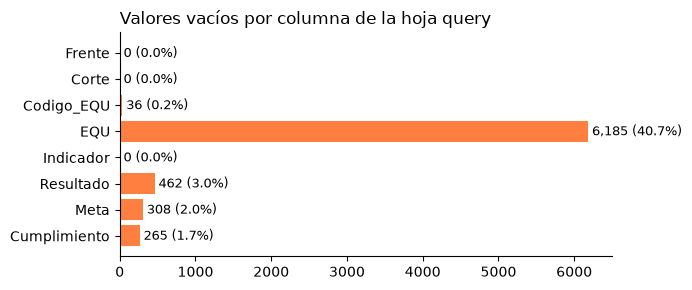

P01 [excluir] Filas sin código de equipo -> 36 filas (0.2%)
P02 [corregir (tomar el nombre del catálogo o de otras filas del mismo código)] Nombre de equipo (EQU) vacío -> 6,185 filas (40.7%)
P03 [corregir las recuperables; excluir el resto] Cumplimiento vacío -> 265 filas (1.7%); 59 se pueden recalcular con Resultado y Meta


In [2]:
vacios = kpis.drop(columns="codigo_equipo").isna().sum()
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(vacios.index[::-1], vacios.values[::-1], color=[NARANJA if v else GRIS for v in vacios.values[::-1]])
for i, v in enumerate(vacios.values[::-1]):
    ax.text(v + 50, i, f"{v:,} ({v / TOTAL:.1%})", va="center", fontsize=9)
ax.set_title("Valores vacíos por columna de la hoja query", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

registrar("Filas sin código de equipo", pct(vacios["Codigo_EQU"]),
          "La medición no se puede asignar a ningún equipo ni entorno.", "excluir")
registrar("Nombre de equipo (EQU) vacío", pct(vacios["EQU"]),
          "Reportes sin nombre legible; el código sí está.", "corregir (tomar el nombre del catálogo o de otras filas del mismo código)")

sin_cumplimiento = kpis["Cumplimiento"].isna()
recuperable = sin_cumplimiento & kpis["Resultado"].notna() & kpis["Meta"].notna()
registrar("Cumplimiento vacío", f"{pct(sin_cumplimiento.sum())}; {recuperable.sum()} se pueden recalcular con Resultado y Meta",
          "Mediciones que no cuentan en el desempeño del equipo.", "corregir las recuperables; excluir el resto")


## 2. Filas repetidas


In [3]:
repetidas = kpis.duplicated(subset=["Frente", "Corte", "Codigo_EQU", "EQU", "Indicador", "Resultado", "Meta", "Cumplimiento"])
mes_top = kpis.loc[repetidas, "Corte"].value_counts()
registrar("Filas repetidas exactamente iguales",
          pct(repetidas.sum()) + f"; {mes_top.iloc[0] / repetidas.sum():.0%} están en {mes_top.index[0]}",
          "Cuentan doble a algunos equipos y meses e inflan promedios.", "excluir (se deja una)")

llave = ["Corte", "codigo_equipo", "Indicador"]
unicas = kpis[~repetidas & kpis["codigo_equipo"].notna()]
conflicto = unicas[unicas.duplicated(llave, keep=False)]
encuesta = conflicto[(conflicto["Corte"] == "202502") & conflicto["Indicador"].isin(["Percepción", "Adopción"])]
registrar("Mismo equipo, indicador y mes con valores distintos",
          f"{len(conflicto):,} filas; {len(encuesta)} son respuestas individuales de encuesta (Percepción/Adopción 202502)",
          "No hay un único valor oficial del mes y los equipos con más respuestas pesan más.",
          "corregir (promedio por equipo, indicador y mes)")


P04 [excluir (se deja una)] Filas repetidas exactamente iguales -> 2,182 filas (14.4%); 56% están en 202502
P05 [corregir (promedio por equipo, indicador y mes)] Mismo equipo, indicador y mes con valores distintos -> 1,265 filas; 962 son respuestas individuales de encuesta (Percepción/Adopción 202502)


## 3. Códigos y nombres que no cruzan con los catálogos


In [4]:
mal_escrito = kpis["Codigo_EQU"].notna() & (kpis["Codigo_EQU"] != kpis["codigo_equipo"])
registrar("Código de equipo mal escrito (minúsculas o dígitos de menos)",
          f"{pct(mal_escrito.sum())}; {kpis['Codigo_EQU'].nunique()} escrituras para {kpis['codigo_equipo'].nunique()} equipos",
          "Un mismo equipo parece varios equipos distintos.", "corregir (mayúsculas y 5 dígitos)")

fantasma = kpis["codigo_equipo"].notna() & ~kpis["codigo_equipo"].isin(cat_entornos["Codigo_EQU"])
ultimo_mes = kpis[fantasma].groupby("codigo_equipo")["Corte"].max()
registrar("Equipos fantasma (en la base, no en el catálogo de entornos)",
          f"{fantasma[fantasma].index.size:,} filas de {ultimo_mes.size} equipos; {(ultimo_mes >= '202601').sum()} siguen activos en 2026",
          "No se pueden agrupar por entorno.", "marcar como 'Sin entorno' y reportar los activos al dueño del catálogo")

padre = kpis["codigo_equipo"].map(cat_entornos.set_index("Codigo_EQU")["Codigo_Padre"])
no_entorno = padre.notna() & ~padre.str.startswith("ENX", na=False)
registrar("Equipos cuyo padre es una vicepresidencia o 'sin entorno'",
          f"{pct(no_entorno.sum())} de {kpis.loc[no_entorno, 'codigo_equipo'].nunique()} equipos",
          "Mezclarlos con entornos compara niveles distintos de la organización.",
          "marcar como 'Sin entorno' conservando la vicepresidencia")

def simplificar(texto):
    return texto.lower().replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")

documentados = set(cat_indicadores["Indicador"].map(simplificar))
no_documentado = ~kpis["Indicador"].map(simplificar).isin(documentados)
registrar("Indicadores sin definición en el catálogo",
          f"{kpis.loc[no_documentado, 'Indicador'].nunique()} de {kpis['Indicador'].nunique()} indicadores; {pct(no_documentado.sum())}",
          "No se sabe qué miden, en qué unidad ni si más alto es mejor.",
          "marcar y documentar con el dueño del indicador")

sin_equipos = cat_indicadores[~cat_indicadores["Indicador"].map(simplificar).isin(set(kpis["Indicador"].map(simplificar)))]
registrar("Indicadores del catálogo que ningún equipo mide",
          f"{len(sin_equipos)}: {', '.join(sin_equipos['Indicador'])} (misma definición)",
          "Catálogo desactualizado o índice consolidado que no llega a la base.", "aceptar y reportar")

frentes = kpis["Frente"].isin(["Talento + Agilidad", "Modeos de trabajo y Agilidad"])
registrar("Un mismo frente con tres nombres (Talento + Agilidad, Modelos…, Modeos…)", pct(frentes.sum()),
          "El histórico del frente se ve cortado en tres frentes distintos.",
          "corregir (homologar a 'Modelos de trabajo y Agilidad', también en el catálogo)")


P06 [corregir (mayúsculas y 5 dígitos)] Código de equipo mal escrito (minúsculas o dígitos de menos) -> 325 filas (2.1%); 146 escrituras para 89 equipos
P07 [marcar como 'Sin entorno' y reportar los activos al dueño del catálogo] Equipos fantasma (en la base, no en el catálogo de entornos) -> 1,473 filas de 26 equipos; 8 siguen activos en 2026
P08 [marcar como 'Sin entorno' conservando la vicepresidencia] Equipos cuyo padre es una vicepresidencia o 'sin entorno' -> 2,218 filas (14.6%) de 13 equipos
P09 [marcar y documentar con el dueño del indicador] Indicadores sin definición en el catálogo -> 14 de 25 indicadores; 8,267 filas (54.4%)
P10 [aceptar y reportar] Indicadores del catálogo que ningún equipo mide -> 2: Adopción de la metodologia, Productividad (misma definición)
P11 [corregir (homologar a 'Modelos de trabajo y Agilidad', también en el catálogo)] Un mismo frente con tres nombres (Talento + Agilidad, Modelos…, Modeos…) -> 3,089 filas (20.3%)


## 4. ¿El cumplimiento significa lo mismo en todos los indicadores?

Se compara la mediana del cumplimiento por indicador: en los indicadores de encuesta es el puntaje (≈ 4.4 sobre 5), en el resto es resultado contra meta (≈ 1.0).


In [5]:
mediana = kpis.groupby("Indicador")["Cumplimiento"].median().sort_values(ascending=False)
display(mediana.head(5).round(2).to_frame("mediana_cumplimiento"))

encuestas = kpis["Indicador"].isin(["Percepción", "Adopción", "Talento + Agilidad"])
metas = kpis[kpis["Indicador"].isin(["Percepción", "Adopción"])].groupby(kpis["Corte"].str[:4])["Meta"].agg(lambda s: sorted(s.unique()))
print(metas.to_string())
registrar("Cumplimiento en escalas distintas: encuestas reportan el puntaje, no el % de la meta",
          f"{pct(encuestas.sum())}; mediana 4.4 vs 1.0 del resto; la meta de encuesta cambia de 10 a 4 y a 5",
          "Promediar cumplimientos favorece 4 veces a los equipos medidos por encuesta.",
          "corregir (cumplimiento = Resultado / Meta)")


,mediana_cumplimiento
Indicador,
Percepción,4.61
Adopción,4.61
Talento + Agilidad,4.53
"Impactos a clientes activos por fricciones, quejas y requerimientos",1.20
Cierre de vulnerabilidades,1.17


Corte
2023        [10.0]
2024         [4.0]
2025    [4.0, 5.0]
P12 [corregir (cumplimiento = Resultado / Meta)] Cumplimiento en escalas distintas: encuestas reportan el puntaje, no el % de la meta -> 5,498 filas (36.2%); mediana 4.4 vs 1.0 del resto; la meta de encuesta cambia de 10 a 4 y a 5


## 5. Valores que no parecen mediciones reales


In [6]:
extremos = kpis[(kpis["Cumplimiento"].abs() > 3) & ~encuestas]
display(extremos.groupby(["Indicador", "Corte"])["Cumplimiento"].agg(filas="size", minimo="min", maximo="max"))
registrar("Cumplimientos imposibles (Incidentes 202408 = 155.4 en 19 equipos; Gestión del Gasto hasta -1873)",
          f"{len(extremos)} filas",
          "Una sola fila extrema domina cualquier promedio.", "marcar y excluir del análisis")

copiado = np.isclose(kpis["Cumplimiento"], 1.014683, atol=1e-6)
resultados = kpis.loc[copiado, "Resultado"].nunique()
registrar("Mismo cumplimiento (1.014683) repetido con resultados distintos",
          f"{pct(copiado.sum())} en Disponibilidad e Incidentes, con {resultados} resultados distintos",
          "Parece un valor por defecto copiado, no una medición.", "marcar y excluir del análisis")


,,filas,minimo,maximo
Indicador,Corte,,,
Gestión del Gasto,202308,3,-1872.998223,-8.752664
Incidentes,202408,19,155.421480,155.421480


P13 [marcar y excluir del análisis] Cumplimientos imposibles (Incidentes 202408 = 155.4 en 19 equipos; Gestión del Gasto hasta -1873) -> 22 filas
P14 [marcar y excluir del análisis] Mismo cumplimiento (1.014683) repetido con resultados distintos -> 530 filas (3.5%) en Disponibilidad e Incidentes, con 376 resultados distintos


## 6. Meses con pocos equipos reportando


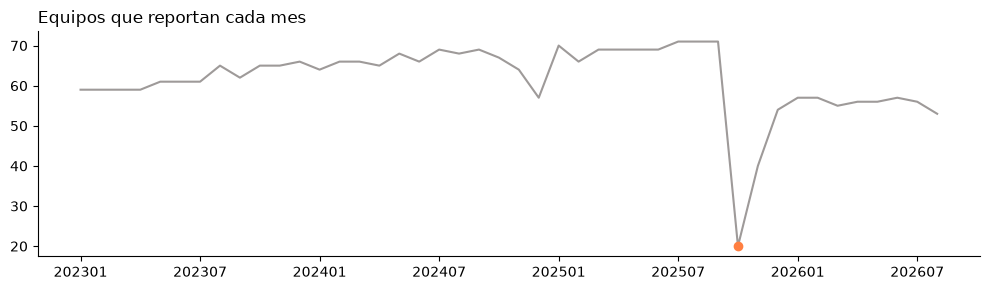

P15 [marcar (mostrar siempre cuántos equipos hay detrás de cada cifra)] Meses con menos de la mitad de los equipos reportando -> 202510: 20 equipos (normal: 64)


In [7]:
equipos_mes = kpis.groupby("Corte")["codigo_equipo"].nunique()
bajos = equipos_mes[equipos_mes < equipos_mes.median() / 2]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(equipos_mes.index, equipos_mes.values, color=GRIS)
ax.scatter(bajos.index, bajos.values, color=NARANJA, zorder=3)
ax.set_xticks(equipos_mes.index[::6])
ax.set_title("Equipos que reportan cada mes", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
registrar("Meses con menos de la mitad de los equipos reportando",
          ", ".join(f"{m}: {n} equipos" for m, n in bajos.items()) + f" (normal: {equipos_mes.median():.0f})",
          "El promedio del mes representa a pocos equipos.", "marcar (mostrar siempre cuántos equipos hay detrás de cada cifra)")


## Registro de calidad


In [8]:
registro = pd.DataFrame(registro)
registro.to_csv(SALIDA, index=False, encoding="utf-8-sig")
print("registro | problemas:", len(registro), "| guardado:", SALIDA)
display(registro)


registro | problemas: 15 | guardado: ..\resultados\registro_calidad.csv


,id,problema,evidencia,impacto,tratamiento
0,P01,Filas sin código de equipo,36 filas (0.2%),La medición no se puede asignar a ningún equipo ni entorno.,excluir
1,P02,Nombre de equipo (EQU) vacío,"6,185 filas (40.7%)",Reportes sin nombre legible; el código sí está.,corregir (tomar el nombre del catálogo o de otras filas del mismo código)
2,P03,Cumplimiento vacío,265 filas (1.7%); 59 se pueden recalcular con Resultado y Meta,Mediciones que no cuentan en el desempeño del equipo.,corregir las recuperables; excluir el resto
3,P04,Filas repetidas exactamente iguales,"2,182 filas (14.4%); 56% están en 202502",Cuentan doble a algunos equipos y meses e inflan promedios.,excluir (se deja una)
4,P05,"Mismo equipo, indicador y mes con valores distintos","1,265 filas; 962 son respuestas individuales de encuesta (Percepción/Adopción 202502)",No hay un único valor oficial del mes y los equipos con más respuestas pesan más.,"corregir (promedio por equipo, indicador y mes)"
5,P06,Código de equipo mal escrito (minúsculas o dígitos de menos),325 filas (2.1%); 146 escrituras para 89 equipos,Un mismo equipo parece varios equipos distintos.,corregir (mayúsculas y 5 dígitos)
6,P07,"Equipos fantasma (en la base, no en el catálogo de entornos)","1,473 filas de 26 equipos; 8 siguen activos en 2026",No se pueden agrupar por entorno.,marcar como 'Sin entorno' y reportar los activos al dueño del catálogo
7,P08,Equipos cuyo padre es una vicepresidencia o 'sin entorno',"2,218 filas (14.6%) de 13 equipos",Mezclarlos con entornos compara niveles distintos de la organización.,marcar como 'Sin entorno' conservando la vicepresidencia
8,P09,Indicadores sin definición en el catálogo,"14 de 25 indicadores; 8,267 filas (54.4%)","No se sabe qué miden, en qué unidad ni si más alto es mejor.",marcar y documentar con el dueño del indicador
9,P10,Indicadores del catálogo que ningún equipo mide,"2: Adopción de la metodologia, Productividad (misma definición)",Catálogo desactualizado o índice consolidado que no llega a la base.,aceptar y reportar
